In [ ]:
t_fname = 'Alice.txt'
d_fname = 'Analogy.txt'
m_fname = 'FastText.bin'

In [ ]:
dim = 300
sg = 0


In [ ]:
import nltk

In [ ]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [ ]:
file = open(t_fname, 'r', encoding='utf8')
text = file.read()
text = text.replace('\n', ' ')
text = text.replace('\t', ' ')
text = text.replace(' ', ' ')
text = text.lower()


In [ ]:
from nltk.tokenize import sent_tokenize
from nltk.tokenize import word_tokenize

In [ ]:
sentences = sent_tokenize(text)
for i in range(0, len(sentences)):
  temp = sentences[i]
  sentences[i] = word_tokenize(temp)

In [ ]:
from gensim.models import Word2Vec
from gensim.models.fasttext import FastText

In [ ]:
model = FastText(sentences, sg=sg, vector_size=dim, min_count=10, window=5)

In [ ]:
print(model)

FastText<vocab=389, vector_size=300, alpha=0.025>


In [ ]:
words = list(model.wv.key_to_index)
print(words)

[',', 'the', '`', "'", '.', 'and', 'to', 'a', 'it', 'she', 'i', 'of', 'said', '!', 'you', 'alice', 'was', 'in', 'that', 'as', '--', 'her', ':', "n't", 'at', '?', "'s", ';', 'on', 'had', 'all', 'with', 'but', 'for', 'they', 'so', 'be', 'not', 'very', 'do', 'what', 'this', 'little', 'he', 'is', 'out', 'one', 'down', 'there', 'up', 'if', 'his', 'would', 'then', 'about', 'no', 'them', 'have', 'know', 'could', 'were', 'like', 'herself', 'went', 'again', 'when', 'or', 'did', 'queen', 'thought', 'off', 'time', 'me', 'how', 'into', 'see', '``', 'who', 'king', 'your', '*', 'now', 'well', "'m", 'turtle', 'began', 'my', 'by', "'ll", 'an', 'hatter', 'its', '(', ')', 'quite', 'mock', 'gryphon', 'are', 'think', 'way', 'their', 'say', 'just', 'some', 'first', 'here', 'much', 'head', 'only', 'go', 'thing', 'more', 'which', 'voice', 'rabbit', "''", 'never', 'get', 'come', 'looked', 'oh', 'got', "'ve", 'must', 'him', 'mouse', 'after', 'duchess', 'round', 'such', 'dormouse', 'tone', 'came', 'over', 'why'

In [ ]:
print(model.wv.get_vector("the", norm=True))

[-2.63105961e-03  1.10481931e-02 -5.45064546e-02  1.63851082e-02
  2.05301922e-02 -9.17927176e-02 -1.36288106e-02  1.38776302e-01
  9.06621814e-02 -1.53235886e-02 -8.29500407e-02  5.33592068e-02
 -4.50389320e-03 -8.75764489e-02  5.78782931e-02 -4.48359586e-02
  5.64299226e-02 -9.62210149e-02  8.16226937e-03 -5.95818236e-02
 -8.56761113e-02  2.78606322e-02 -3.01077440e-02 -6.90578967e-02
  9.03658047e-02  7.18154758e-02 -7.59273544e-02 -1.65969075e-03
  2.20042206e-02 -9.76539701e-02  6.18225597e-02  3.86678912e-02
  6.45882171e-03 -2.83978246e-02 -1.16590627e-01  2.87757944e-02
 -3.76796313e-02 -4.51075211e-02  1.00408830e-01  1.27066066e-02
 -3.72807086e-02  6.82253717e-03  9.01197493e-02 -4.93363701e-02
  1.38767492e-02 -1.96501054e-02 -9.14746001e-02  7.07425848e-02
  1.49788484e-02  7.94516057e-02  3.64126712e-02  5.15028313e-02
  1.57708069e-03 -1.18818413e-02 -8.77291411e-02 -8.34866602e-04
  3.42430100e-02  8.01254623e-03  7.71948546e-02 -6.11167476e-02
  2.85182353e-02 -4.86561

In [ ]:
model.save(m_fname)


In [ ]:
model = FastText.load(m_fname)
print(model)

FastText<vocab=389, vector_size=300, alpha=0.025>


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE


In [ ]:
vocab = list(model.wv.key_to_index) #model.wv.vocab에서 변경
X = model.wv[vocab] #model[vocab]이 아니라 model.wv로 변경

In [ ]:
size = len(vocab)
X_show = X[:size,:]
vocab_show = vocab[:size]

In [ ]:
def show_pca():
  pca = PCA(n_components=2)
  pca.fit(X_show)
  x_pca = pca.transform(X_show)

  plt.figure(figsize=(15, 10))
  plt.xlim(x_pca[:, 0].min(), x_pca[:, 0].max())
  plt.ylim(x_pca[:, 1].min(), x_pca[:, 1].max())

  for i in range(len(X_show)):
    plt.text(x_pca[i, 0], x_pca[i, 1], str(vocab_show[i]), fontdict={'weight': 'bold', 'size': 9})
  plt.xlabel("1st Principal Component")
  plt.ylabel("2nd Principal Component")
  plt.show()

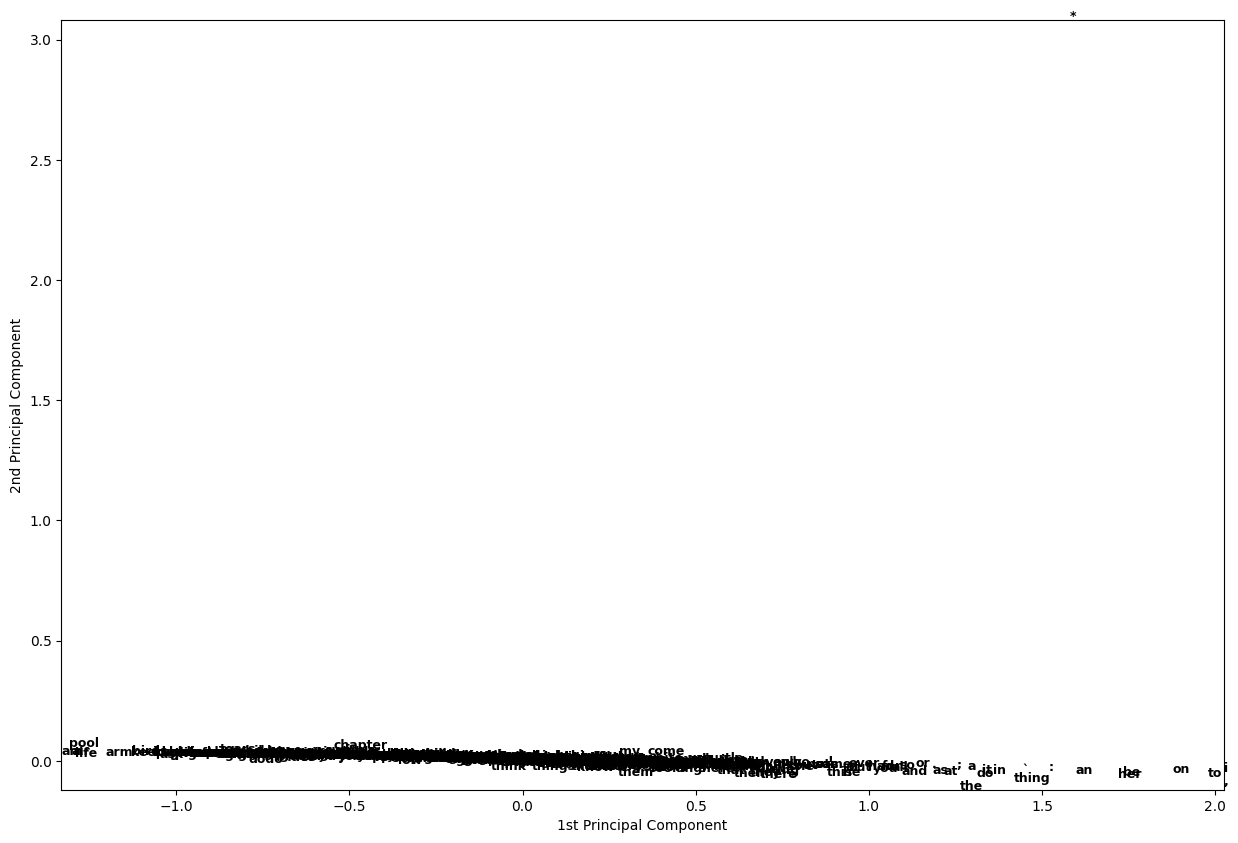

In [ ]:
show_pca()


In [ ]:
def show_tsne():
  tsne = TSNE(n_components=2)
  X = tsne.fit_transform(X_show)

  df = pd.DataFrame(X, index=vocab_show, columns=['x', 'y'])
  fig = plt.figure()
  fig.set_size_inches(15, 10)
  ax = fig.add_subplot(1, 1, 1)
  ax.scatter(df['x'], df['y'])

  plt.xlabel("t-SNE Characteristic 0")
  plt.ylabel("t-SNE Characteristic 1")
  plt.show()

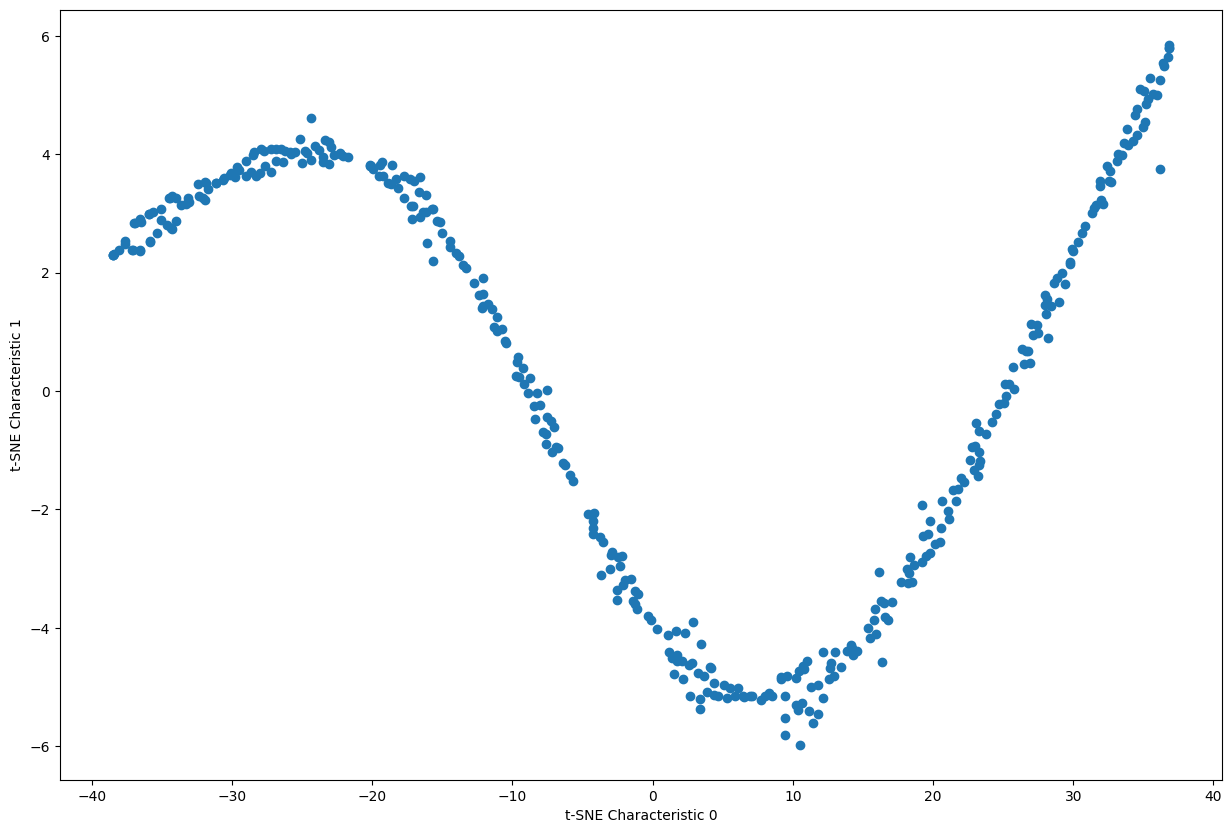

In [ ]:
show_tsne()


In [ ]:
d_df = pd.DataFrame(columns=['Word1', 'Word2', 'Word3', 'Word4'])
i_file = open(d_fname, 'r', encoding='utf8')
text_cont = i_file.readlines()
d_fnum = len(text_cont)
for i in range(0,d_fnum):
  text_line = text_cont[i]
  token = text_line.split()
  d_df = d_df.append(pd.DataFrame([[token[0], token[1], token[2], token[3]]], columns=['Word1', 'Word2', 'Word3', 'Word4']), ignore_index=True)
i_file.close()


<ipython-input-87-f89252280027>:8: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  d_df = d_df.append(pd.DataFrame([[token[0], token[1], token[2], token[3]]], columns=['Word1', 'Word2', 'Word3', 'Word4']), ignore_index=True)
<ipython-input-87-f89252280027>:8: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  d_df = d_df.append(pd.DataFrame([[token[0], token[1], token[2], token[3]]], columns=['Word1', 'Word2', 'Word3', 'Word4']), ignore_index=True)
<ipython-input-87-f89252280027>:8: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  d_df = d_df.append(pd.DataFrame([[token[0], token[1], token[2], token[3]]], columns=['Word1', 'Word2', 'Word3', 'Word4']), ignore_index=True)
<ipython-input-87-f89252280027>:8: FutureWarning: The frame.appe

In [ ]:
m_item = 0
c_item = 0
scores = 0


In [ ]:
for i in range(0, d_fnum):
  word1 = d_df.iloc[i, 0]
  word2 = d_df.iloc[i, 1]
  word3 = d_df.iloc[i, 2]
  word4 = d_df.iloc[i, 3]
  if ((word1 in vocab) & (word2 in vocab) & (word3 in vocab)):
    m_item = m_item + 1
    s_word = model.most_similar(positive=[word1, word3], negative=[word2], topn=5)
    for j in range(0, 5):
      if (s_word[j][0]==word4):
        c_item = c_item + 1
        scores = scores + 5 - j


In [ ]:
value = round(m_item/d_fnum*100, 3)
print('The percentage of the matched analogy: ' + str(value))

The percentage of the matched analogy: 0.98


In [ ]:
value = round(c_item/m_item*100, 3)
print('The percentage of the correct match: ' + str(value))

The percentage of the correct match: 0.0


In [ ]:
value = round((scores/(m_item*5))*100, 3)
print('The similarity scores of the matched analogy: ' + str(value))

The similarity scores of the matched analogy: 0.0


In [ ]:
value = round((scores/(c_item*5))*100, 3)
print('The similarity scores of the correct match: ' + str(value))

ZeroDivisionError: ignored

In [ ]:
import gensim.downloader

In [ ]:
print(list(gensim.downloader.info()['models'].keys()))


['fasttext-wiki-news-subwords-300', 'conceptnet-numberbatch-17-06-300', 'word2vec-ruscorpora-300', 'word2vec-google-news-300', 'glove-wiki-gigaword-50', 'glove-wiki-gigaword-100', 'glove-wiki-gigaword-200', 'glove-wiki-gigaword-300', 'glove-twitter-25', 'glove-twitter-50', 'glove-twitter-100', 'glove-twitter-200', '__testing_word2vec-matrix-synopsis']


In [ ]:
model = gensim.downloader.load('fasttext-wiki-news-subwords-300')

In [ ]:
model.most_similar('watch')

[('watching', 0.8072217106819153),
 ('watches', 0.772962212562561),
 ('re-watch', 0.765845537185669),
 ('watched', 0.7582172155380249),
 ('watch-', 0.7325752973556519),
 ('rewatch', 0.7286353707313538),
 ('stop-watch', 0.7167803645133972),
 ('copwatch', 0.7092429399490356),
 ('watchout', 0.7014285922050476),
 ('binge-watch', 0.6974658966064453)]

In [ ]:
model.most_similar(positive=['watch', 'listen'], negative=['watched'], topn=5)


[('hear', 0.6634597778320312),
 ('speak', 0.5844764709472656),
 ('listening', 0.5798445343971252),
 ('sit', 0.5782521963119507),
 ('listen.', 0.5639269351959229)]